In [37]:
from calendar import week

import numpy as np
import pandas as pd
from matplotlib.pyplot import xlabel, title
from pandas import DatetimeIndex

In [33]:
# E и S отвечают за вывод начала или конца фрактала
print(pd.date_range('2026-01-01', periods=4, freq='ME'))
print(pd.date_range('2026-01-01', periods=4, freq='MS'))
print(pd.date_range('2026-01-01', periods=4, freq='QE'))
print(pd.date_range('2026-01-01', periods=4, freq='QS'))
print(pd.date_range('2026-01-01', periods=4, freq='W'))
print(pd.date_range('2026-01-01', periods=4, freq='W-MON'))

DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30'], dtype='datetime64[us]', freq='ME')
DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01'], dtype='datetime64[us]', freq='MS')
DatetimeIndex(['2026-03-31', '2026-06-30', '2026-09-30', '2026-12-31'], dtype='datetime64[us]', freq='QE-DEC')
DatetimeIndex(['2026-01-01', '2026-04-01', '2026-07-01', '2026-10-01'], dtype='datetime64[us]', freq='QS-JAN')
DatetimeIndex(['2026-01-04', '2026-01-11', '2026-01-18', '2026-01-25'], dtype='datetime64[us]', freq='W-SUN')
DatetimeIndex(['2026-01-05', '2026-01-12', '2026-01-19', '2026-01-26'], dtype='datetime64[us]', freq='W-MON')


In [49]:
ind = pd.read_csv('/Users/adil.murat/PycharmProjects/ml_formula/data/index.csv', sep=';', parse_dates=['Date'])
print(ind.head())
print(type(ind))
print(ind.dtypes)

        Date    Open    High     Low   Close  Adj Close    Volume
0 2026-03-11  105.14  114.08  104.49  109.34     109.34  24466129
1 2026-03-10   95.14   98.40   95.00   96.43      96.43   7052100
2 2026-03-09   87.36   95.20   86.50   94.94      94.94   9983800
3 2026-03-06   92.30   94.95   88.80   89.33      89.33   7829400
4 2026-03-05   96.75   99.25   91.62   95.65      95.65   8769300
<class 'pandas.DataFrame'>
Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [50]:
index = pd.DatetimeIndex(ind["Date"])
print(index)
ind.index = index
ind = ind["Close"]
print(ind.head())

DatetimeIndex(['2026-03-11', '2026-03-10', '2026-03-09', '2026-03-06',
               '2026-03-05', '2026-03-04', '2026-03-03', '2026-03-02',
               '2026-02-27', '2026-02-26',
               ...
               '2025-03-24', '2025-03-21', '2025-03-20', '2025-03-19',
               '2025-03-18', '2025-03-17', '2025-03-14', '2025-03-13',
               '2025-03-12', '2025-03-11'],
              dtype='datetime64[us]', name='Date', length=252, freq=None)
Date
2026-03-11    109.34
2026-03-10     96.43
2026-03-09     94.94
2026-03-06     89.33
2026-03-05     95.65
Name: Close, dtype: float64


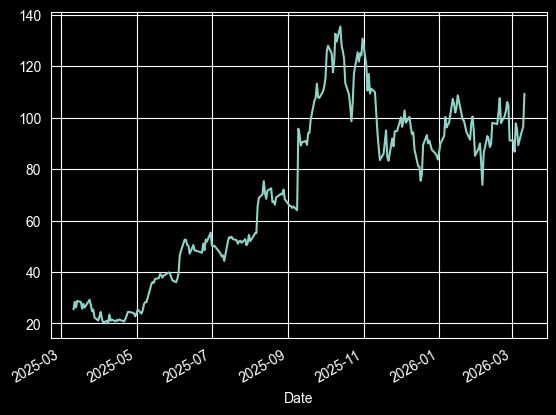

In [51]:
import matplotlib.pyplot as plt
ind.plot()
plt.show()

In [55]:
df = pd.read_csv(
    "/Users/adil.murat/PycharmProjects/ml_formula/data/FremontBridge.csv",
    index_col="Date",
    parse_dates=True,
    #  date_format = "%Y-%m-%d %I:%M:%S %p"
    date_format="%m/%d/%Y %I:%M:%S %p")

print(df.head())
print(df.dtypes)
print(df.columns)
df.columns = ['Total', 'East', "West"]
print(df.head())

print(df.describe())
print(df.dropna().describe())

                     Fremont Bridge Total  Fremont Bridge East Sidewalk  \
Date                                                                      
2019-11-01 00:00:00                  12.0                           7.0   
2019-11-01 01:00:00                   7.0                           0.0   
2019-11-01 02:00:00                   1.0                           0.0   
2019-11-01 03:00:00                   6.0                           6.0   
2019-11-01 04:00:00                   6.0                           5.0   

                     Fremont Bridge West Sidewalk  
Date                                               
2019-11-01 00:00:00                           5.0  
2019-11-01 01:00:00                           7.0  
2019-11-01 02:00:00                           1.0  
2019-11-01 03:00:00                           0.0  
2019-11-01 04:00:00                           1.0  
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk  

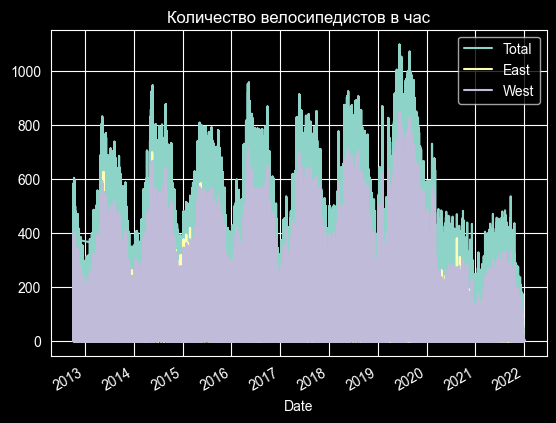

In [56]:
# df.plot()
# plt.title('Количество велосипедистов в час')
# plt.show()

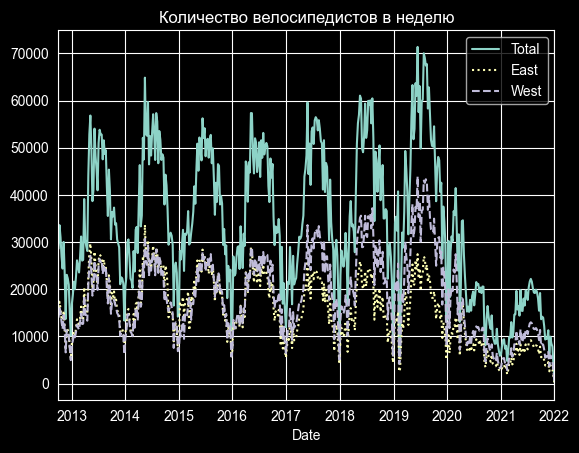

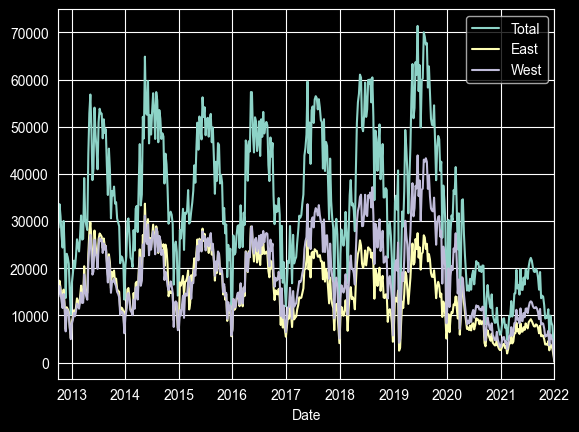

In [59]:
# weekly = df.resample("W").sum()
# weekly.plot(style=['-', ':', '--'])
# plt.title('Количество велосипедистов в неделю')
# weekly.plot()
# plt.show()

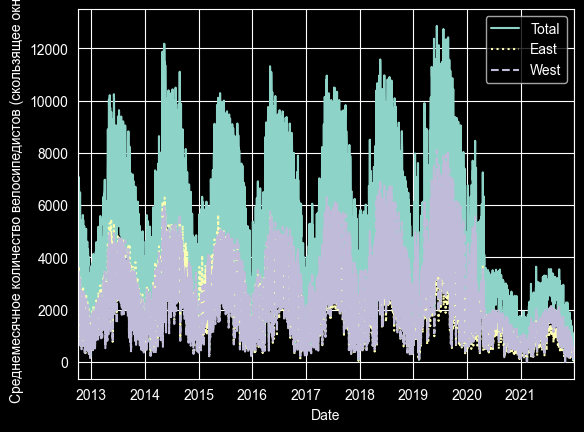

In [71]:
# daily = df.resample('D').sum()
# daily.rolling(30, center=True)
# daily.plot(style=['-', ':', '--'])
# plt.ylabel('Среднемесячное количество велосипедистов (скользящее окно)')
# plt.show()

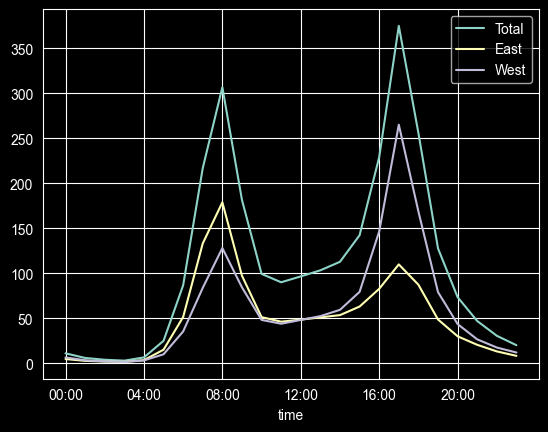

In [75]:
# timely = df.groupby(df.index.time).mean()
# ticks = 60 * 60 * 4*np.arange(6)
# timely.plot(xticks=ticks)
# plt.show()

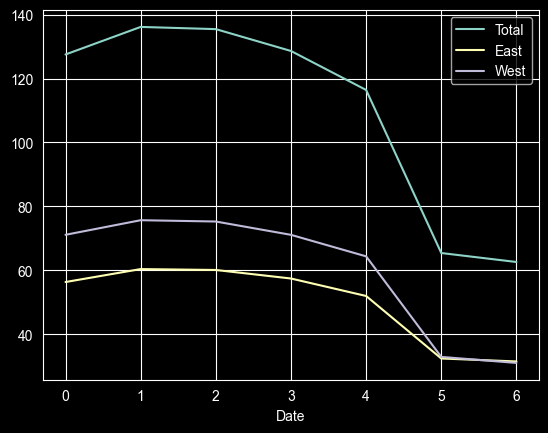

In [78]:
weekly = df.groupby(df.index.dayofweek).mean()
weekly.plot()
plt.show()

<Axes: title={'center': 'выходные'}, xlabel='time'>

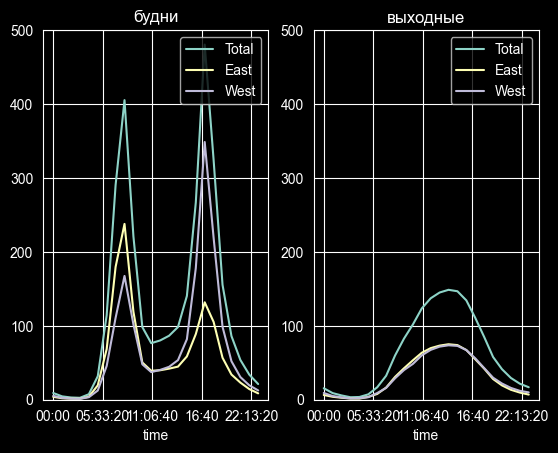

In [83]:
w1 = np.where(df.index.weekday < 5, "будни", "выходные")
t1 = df.groupby([w1, df.index.time]).mean()

fig, ax = plt.subplots(1, 2)
ax[0].set_ylim(0, 500)
t1.loc["будни"].plot(ax=ax[0], title = "будни")
ax[1].set_ylim(0, 500)
t1.loc["выходные"].plot(ax=ax[1], title = "выходные")

In [84]:
# MATPLOTLIB

# import matplotlib.pyplot as plt

# plt.style.use('classic')
# plt.show() # Должно быть в единственном экземпляре
# fig.savefig('ttt.png')
# from IPython import Image
# Image('ttt.png')

